# 03 — Feature Analysis

Descriptive boxplots and the three families of Welch t-tests reported in the manuscript appendix (Tables VI/VII/VIII): fixation/saccade metrics, per-HDA metrics for Exploration 1 (k=6), and aggregated min/max HDA metrics for Exploration 1 (k=6) -- each across three cohort comparisons (PD vs HC, yHC vs HC, PD vs all-Ctrl). Ends with Benjamini-Hochberg FDR correction applied separately within each family.

Independently runnable: loads `sacfix_metrics`/`gmm_metrics`/`group_labels` from `../pkls/`, produced by `02_feature_creation.ipynb`.

Part of the pipeline: 01 exploratory data analysis → 02 feature creation → **03 (this notebook)** → 04 model training → 05 model testing.


In [1]:
# Utilities
import pickle

# Data management
import numpy as np
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Visualization
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
%matplotlib inline

from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests

# Custom utilities
from futils import get_t_tests


In [2]:
with open('../pkls/metrics/fixation_saccade_metrics.pkl', 'rb') as f:
    sacfix_metrics = pickle.load(f)
with open('../pkls/metrics/gmm_metrics.pkl', 'rb') as f:
    gmm_metrics = pickle.load(f)
with open('../pkls/basic/group_labels.pkl', 'rb') as f:
    group_labels = pickle.load(f)

# Define the order of the groups
group_order = ['young control', 'control', 'PD']

group_colours = {
    "young control": "#7bbcd9",  # Light blue for young control
    "control": "#1e6e93",        # Darker blue for control
    "PD": "#a84839"              # Muted red/brown for PD
}


## Fixation/Saccade-Based Features

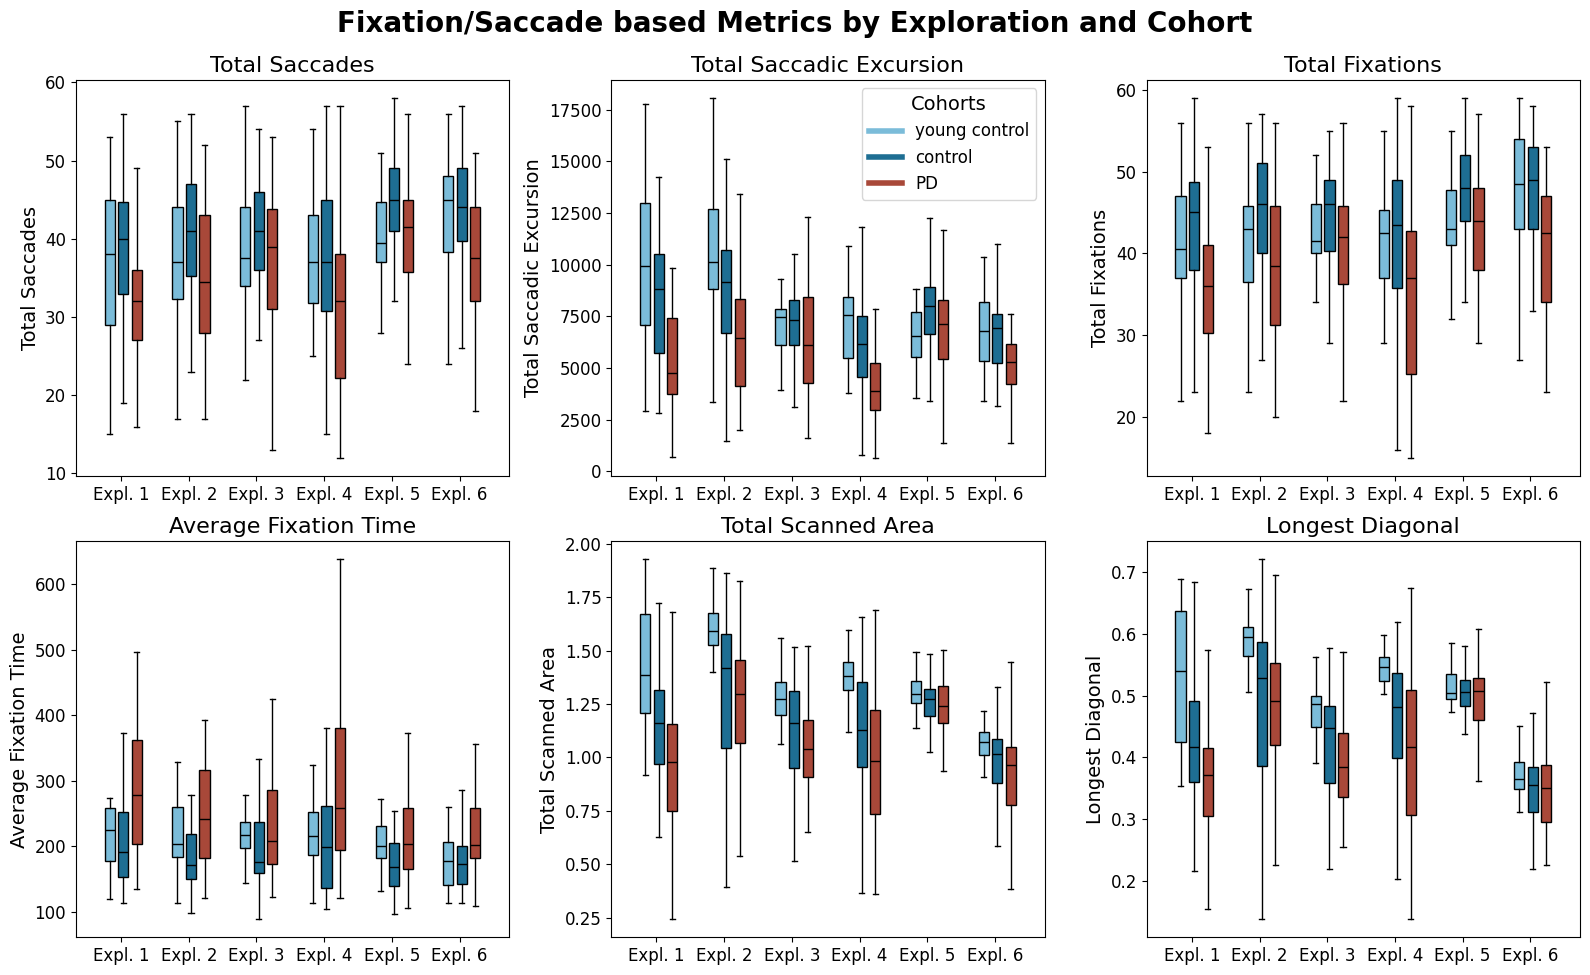

In [3]:
# BOXPLOTS
metrics_info = {
    "total_saccades": "Total Saccades",
    "total_saccadic_excursion": "Total Saccadic Excursion",
    "total_fixations": "Total Fixations",
    "average_fixation_time": "Average Fixation Time",
    "total_scanned_area": "Total Scanned Area",
    "longest_diagonal": "Longest Diagonal",
}

exploration_labels = [f"Expl. {i+1}" for i in range(len(sacfix_metrics['exploration_id'].unique()))]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

handles = []
labels = []

for idx, (metric, nice_title) in enumerate(metrics_info.items()):
    ax = axes[idx]

    data = []
    for exploration in sacfix_metrics['exploration_id'].unique():
        exploration_data = sacfix_metrics[sacfix_metrics['exploration_id'] == exploration]
        for group in group_order:
            group_data = exploration_data[exploration_data['group'] == group][metric]
            data.append((exploration, group, group_data.values))

    positions = []
    color_list = []
    all_data = []
    for i, (exploration, group, values) in enumerate(data):
        all_data.append(values)
        positions.append(i // len(group_order) + (i % len(group_order) * 0.2))
        color_list.append(group_colours[group])
        if idx == 2 and group not in labels:
            handles.append(plt.Line2D([0], [0], color=group_colours[group], lw=4))
            labels.append(group)

    bplot = ax.boxplot(
        all_data, positions=positions, widths=0.15,
        patch_artist=True, showfliers=False, medianprops=dict(color='black')
    )
    for patch, color in zip(bplot['boxes'], color_list):
        patch.set_facecolor(color)

    exploration_ticks = np.arange(0.5, len(exploration_labels) * len(group_order), len(group_order)) / 3
    ax.set_xticks(exploration_ticks)
    ax.set_xticklabels(exploration_labels, fontsize=12)

    ax.set_title(nice_title, fontsize=16)
    ax.set_ylabel(nice_title, fontsize=14)
    ax.tick_params(axis='y', labelsize=12)

axes[1].legend(handles, labels, title="Cohorts", loc="upper right", fontsize=12, title_fontsize=14, frameon=True)
fig.suptitle("Fixation/Saccade based Metrics by Exploration and Cohort", fontsize=20, fontweight="bold", y=0.97)
plt.tight_layout()
plt.subplots_adjust(top=0.90)
plt.savefig("../plots/paper_figures/boxplots_sacfix.png", dpi=300)
plt.show()
plt.close()


#### T-tests

In [4]:
# Helper to format and display each t-test result with subtitle
def format_and_display_ttest_table(ttest_df, subtitle):
    formatted = ttest_df.pivot(index='metric', columns='exploration_id', values='p_value')
    formatted = formatted.reset_index()
    formatted = formatted.map(lambda x: f"{x:.2e}" if isinstance(x, float) else x)
    print(f"\n=== {subtitle} ===")
    display(formatted)

# T-TESTS
t_tests_sacfix = get_t_tests(sacfix_metrics, group_level='group')
t_tests_sacfix_pd_ac = get_t_tests(sacfix_metrics, group_level='group_general')

# PD vs HC
t_pd_hc_sacfix = t_tests_sacfix[
    ((t_tests_sacfix['group_A'] == 'PD') & (t_tests_sacfix['group_B'] == 'control')) |
    ((t_tests_sacfix['group_A'] == 'control') & (t_tests_sacfix['group_B'] == 'PD'))
]

# HC vs yHC
t_hc_yhc_sacfix = t_tests_sacfix[
    ((t_tests_sacfix['group_A'] == 'control') & (t_tests_sacfix['group_B'] == 'young control')) |
    ((t_tests_sacfix['group_A'] == 'young control') & (t_tests_sacfix['group_B'] == 'control'))
]

# PD vs All Control
t_pd_allc_sacfix = t_tests_sacfix_pd_ac  # Already correct comparison

format_and_display_ttest_table(t_pd_hc_sacfix, "PD vs HC")
format_and_display_ttest_table(t_hc_yhc_sacfix, "HC vs Young Control")
format_and_display_ttest_table(t_pd_allc_sacfix, "PD vs All Control")



=== PD vs HC ===


exploration_id,metric,Exploration_1,Exploration_2,Exploration_3,Exploration_4,Exploration_5,Exploration_6
0,average_fixation_time,2.33e-04,3.93e-07,1.72e-01,3.22e-04,1.87e-02,3.58e-02
1,longest_diagonal,4.28e-03,9.57e-01,5.35e-02,2.35e-02,9.80e-01,5.24e-01
2,total_fixations,3.34e-08,2.55e-07,8.38e-03,1.01e-05,3.04e-04,4.72e-06
3,total_saccades,6.99e-08,1.67e-05,2.18e-02,1.19e-04,1.08e-03,4.12e-05
4,total_saccadic_excursion,2.61e-07,3.37e-04,2.66e-02,6.78e-06,1.88e-02,4.33e-04
5,total_scanned_area,1.98e-03,7.60e-01,8.16e-02,1.23e-02,7.51e-01,2.06e-01



=== HC vs Young Control ===


exploration_id,metric,Exploration_1,Exploration_2,Exploration_3,Exploration_4,Exploration_5,Exploration_6
0,average_fixation_time,2.00e-01,1.01e-02,5.53e-01,6.47e-01,1.00e-01,4.78e-01
1,longest_diagonal,3.06e-06,4.30e-09,1.62e-06,3.15e-08,3.73e-03,4.15e-02
2,total_fixations,1.08e-01,4.34e-03,2.14e-01,5.76e-01,8.53e-03,7.09e-01
3,total_saccades,1.80e-01,4.09e-02,5.14e-01,9.28e-01,2.62e-03,9.24e-01
4,total_saccadic_excursion,2.04e-02,1.21e-02,5.82e-01,1.39e-03,5.55e-05,6.61e-01
5,total_scanned_area,1.74e-07,1.14e-10,3.11e-07,8.51e-09,4.81e-04,7.01e-04



=== PD vs All Control ===


exploration_id,metric,Exploration_1,Exploration_2,Exploration_3,Exploration_4,Exploration_5,Exploration_6
0,average_fixation_time,4.44e-04,3.11e-05,1.56e-01,5.76e-05,2.89e-02,5.05e-03
1,longest_diagonal,8.21e-07,5.52e-02,2.11e-04,9.31e-05,4.08e-01,1.51e-01
2,total_fixations,1.04e-07,1.22e-05,1.50e-02,3.43e-06,2.34e-03,1.57e-07
3,total_saccades,2.12e-07,1.41e-04,2.43e-02,2.23e-05,1.44e-02,4.75e-06
4,total_saccadic_excursion,2.57e-10,2.79e-06,2.44e-02,5.44e-09,1.73e-01,8.90e-05
5,total_scanned_area,7.26e-08,1.18e-02,2.90e-04,1.63e-05,1.67e-01,1.16e-02


## HDA-Based Features

For Exploration 1, which has the lowest number of `k`, per-HDA (state) level t-tests and boxplots.


In [5]:
# Map nice names for plotting
state_metrics_info = {
    'FO': 'Fractional Occupancy',
    'MLT': 'Mean Lifetime',
    'MIL': 'Mean Interval Length',
    'entropy': 'Entropy of States'
}

gmm_metrics_expl1_k6 = gmm_metrics[(gmm_metrics['exploration_id'] == "Exploration_1") & (gmm_metrics['k_clusters'] == 6)].copy()


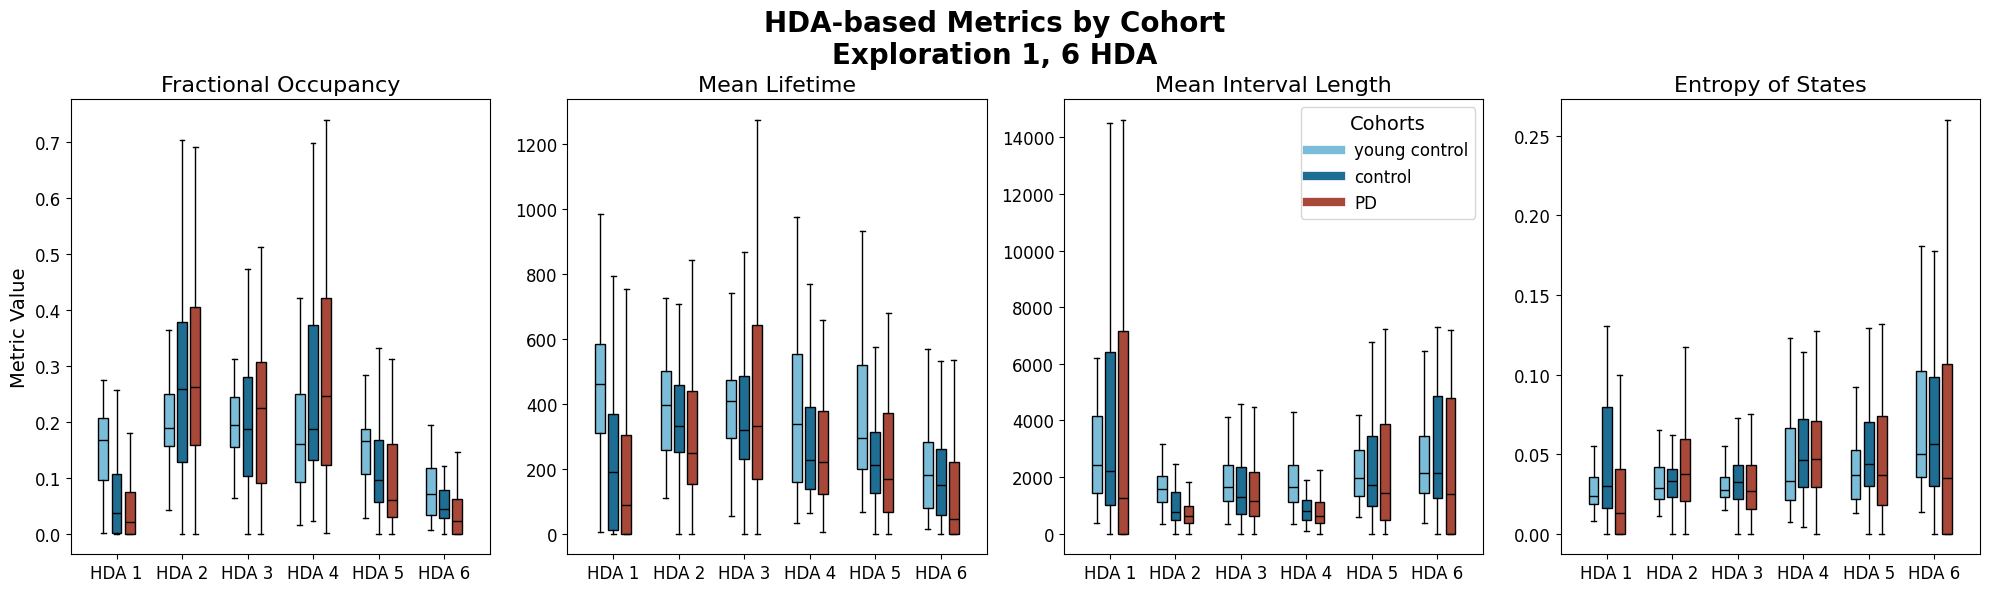

In [6]:
# Get unique states
states = sorted(gmm_metrics_expl1_k6['state'].unique())

fig, axes = plt.subplots(1, len(state_metrics_info), figsize=(5 * len(state_metrics_info), 6), sharey=False)
if len(state_metrics_info) == 1:
    axes = [axes]

for col_idx, (metric, nice_title) in enumerate(state_metrics_info.items()):
    ax = axes[col_idx]

    data, positions, colors, tick_positions = [], [], [], []
    for s_idx, state in enumerate(states):
        base_pos = s_idx
        for g_idx, group in enumerate(group_order):
            values = gmm_metrics_expl1_k6[
                (gmm_metrics_expl1_k6['state'] == state) & (gmm_metrics_expl1_k6['group'] == group)
            ][metric].dropna().values
            data.append(values)
            positions.append(base_pos + g_idx * 0.2)
            colors.append(group_colours[group])
        tick_positions.append(base_pos + 0.2)

    bplot = ax.boxplot(data, positions=positions, widths=0.15, patch_artist=True, showfliers=False,
                        medianprops=dict(color='black'))
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"HDA {s+1}" for s in states], fontsize=12)
    ax.set_title(nice_title, fontsize=16)
    if col_idx == 0:
        ax.set_ylabel("Metric Value", fontsize=14)
    ax.tick_params(axis='y', labelsize=12)

handles = [plt.Line2D([0], [0], color=color, lw=6) for color in group_colours.values()]
labels = list(group_colours.keys())
axes[2].legend(handles, labels, title="Cohorts", loc='upper right', fontsize=12, title_fontsize=14, frameon=True)

fig.suptitle("HDA-based Metrics by Cohort\nExploration 1, 6 HDA", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.83)
plt.savefig("../plots/paper_figures/boxplots_hda_rawmetrics.png", dpi=300)
plt.show()
plt.close()


Now for the max/min features...

In [7]:
# Step 1: Pivot the dataframe
df_pivoted = gmm_metrics_expl1_k6.pivot_table(
    index=['patient_id', 'eye', 'exploration_id'],
    columns='state',
    values=['FO', 'MLT', 'MIL', 'entropy'],
    aggfunc='first'
)
df_pivoted.columns = [f"{metric}_state_{state}" for metric, state in df_pivoted.columns]
df_pivoted = df_pivoted.reset_index()
df_pivoted.fillna(0, inplace=True)

# Step 2: Add back group info
group_info = gmm_metrics_expl1_k6[['patient_id', 'eye', 'group', 'group_general']].drop_duplicates()
df_pivoted = df_pivoted.merge(group_info, on=['patient_id', 'eye'], how='left')

# Step 3: Compute max/min features
for metric in ['FO', 'MLT', 'MIL', 'entropy']:
    metric_cols = [col for col in df_pivoted.columns if col.startswith(f"{metric}_state_")]
    df_pivoted[f"max_{metric}"] = df_pivoted[metric_cols].max(axis=1)
    df_pivoted[f"min_{metric}"] = df_pivoted[metric_cols].min(axis=1)

summary_cols = ['patient_id', 'eye', 'exploration_id', 'group', 'group_general'] + \
               [col for col in df_pivoted.columns if col.startswith('max_') or col.startswith('min_')]
df_summary = df_pivoted[summary_cols]


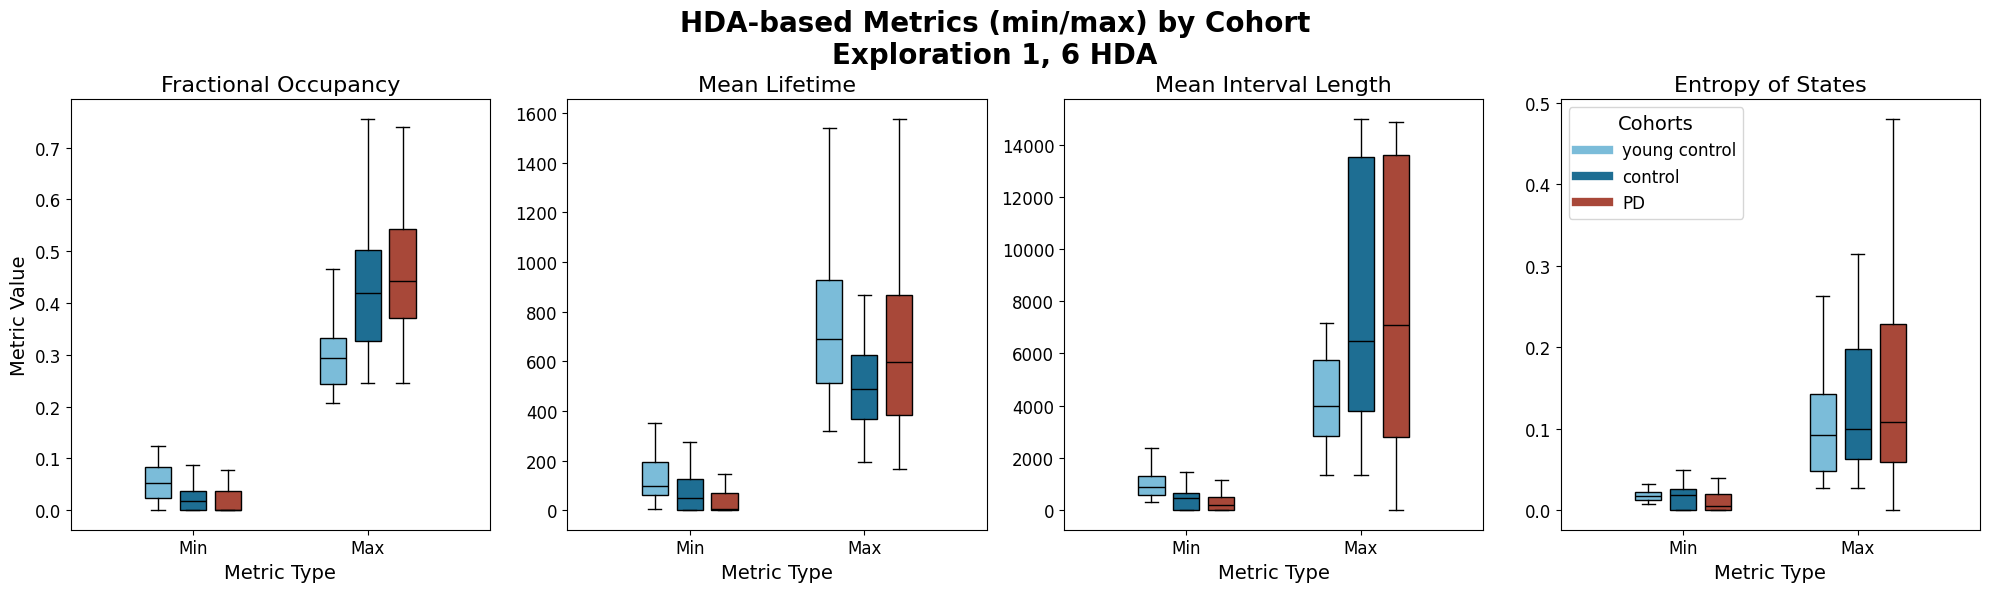

In [8]:
fig, axes = plt.subplots(1, len(state_metrics_info), figsize=(5 * len(state_metrics_info), 6), sharey=False)
if len(state_metrics_info) == 1:
    axes = [axes]

for idx, (metric, nice_title) in enumerate(state_metrics_info.items()):
    ax = axes[idx]
    data, positions, colors = [], [], []

    for m_idx, kind in enumerate(['min', 'max']):
        base_x = m_idx
        for g_idx, group in enumerate(group_order):
            col_name = f"{kind}_{metric}"
            group_values = df_summary[df_summary['group'] == group][col_name].dropna().values
            data.append(group_values)
            positions.append(base_x + g_idx * 0.2)
            colors.append(group_colours[group])

    bplot = ax.boxplot(data, positions=positions, widths=0.15, patch_artist=True, showfliers=False,
                        medianprops=dict(color='black'))
    for patch, color in zip(bplot['boxes'], colors):
        patch.set_facecolor(color)

    ax.set_xticks([0 + 0.2, 1 + 0.2])
    ax.set_xticklabels(['Min', 'Max'], fontsize=12)
    ax.set_title(nice_title, fontsize=16)
    ax.set_xlabel("Metric Type", fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    if idx == 0:
        ax.set_ylabel("Metric Value", fontsize=14)

handles = [plt.Line2D([0], [0], color=color, lw=6) for color in group_colours.values()]
labels = list(group_colours.keys())
axes[-1].legend(handles, labels, title="Cohorts", loc='upper left', fontsize=12, title_fontsize=14, frameon=True)

fig.suptitle("HDA-based Metrics (min/max) by Cohort\nExploration 1, 6 HDA", fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.subplots_adjust(top=0.83)
plt.savefig("../plots/paper_figures/boxplots_hda_minmaxmetrics.png", dpi=300)
plt.show()
plt.close()


#### T-tests

In [9]:
# Helper to format and display state-based t-tests with subtitle
def format_and_display_ttest_table_by_state(ttest_df, subtitle):
    formatted = ttest_df.pivot(index='metric', columns='state', values='p_value')
    formatted = formatted.reset_index()
    formatted = formatted.map(lambda x: f"{x:.2e}" if isinstance(x, float) else x)
    print(f"\n=== {subtitle} ===")
    display(formatted)


def get_t_tests_by_state(metrics_df, group_level='group'):
    # k_clusters excluded too: it's constant within this k=6 subset, so
    # testing it produces a degenerate NaN p-value that would otherwise
    # get folded into the family (and into the BH correction below) as a
    # bogus 5th metric alongside FO/MLT/MIL/entropy.
    exclude_columns = ['patient_id', 'exploration_id', 'eye', 'group', 'group_general', 'state', 'k_clusters']
    metrics = [col for col in metrics_df.columns if col not in exclude_columns]
    for metric in metrics:
        metrics_df[metric] = pd.to_numeric(metrics_df[metric], errors='coerce')
    metrics = [col for col in metrics if pd.api.types.is_numeric_dtype(metrics_df[col])]

    groups = metrics_df[group_level].dropna().unique()
    states = metrics_df['state'].dropna().unique()

    results = []
    for state in states:
        state_data = metrics_df[metrics_df['state'] == state]
        for metric in metrics:
            for i in range(len(groups)):
                for j in range(i + 1, len(groups)):
                    group_A, group_B = groups[i], groups[j]
                    data_A = state_data[state_data[group_level] == group_A][metric]
                    data_B = state_data[state_data[group_level] == group_B][metric]
                    t_statistic, p_value = ttest_ind(data_A, data_B, equal_var=False)
                    results.append({
                        'state': f'state_{state}', 'metric': metric,
                        'group_A': group_A, 'group_B': group_B,
                        't_statistic': t_statistic, 'p_value': p_value,
                        'significant': p_value < 0.05
                    })
    return pd.DataFrame(results)


def get_t_tests_max_min(df, group_level='group'):
    max_min_cols = [col for col in df.columns if col.startswith('max_') or col.startswith('min_')]
    results = []
    for col in max_min_cols:
        base_metric = col.replace("max_", "").replace("min_", "")
        comparison_type = "max" if col.startswith("max_") else "min"
        groups = df[group_level].dropna().unique()
        for i in range(len(groups)):
            for j in range(i + 1, len(groups)):
                group_A, group_B = groups[i], groups[j]
                data_A = df[df[group_level] == group_A][col]
                data_B = df[df[group_level] == group_B][col]
                t_statistic, p_value = ttest_ind(data_A, data_B, equal_var=False)
                results.append({
                    'metric': base_metric, 'comparison': comparison_type,
                    'group_A': group_A, 'group_B': group_B,
                    't_statistic': t_statistic, 'p_value': p_value,
                    'significant': p_value < 0.05
                })
    return pd.DataFrame(results)


def format_and_display_ttest_table_max_min(ttest_df, subtitle):
    formatted = ttest_df.pivot(index='metric', columns='comparison', values='p_value')
    formatted = formatted.reset_index()
    formatted = formatted.map(lambda x: f"{x:.2e}" if isinstance(x, float) else x)
    print(f"\n=== {subtitle} ===")
    display(formatted)


In [10]:
# Run the t-tests by state
t_tests_by_state_group = get_t_tests_by_state(gmm_metrics_expl1_k6, group_level='group')
t_tests_by_state_group_general = get_t_tests_by_state(gmm_metrics_expl1_k6, group_level='group_general')

t_pd_hc_state = t_tests_by_state_group[
    ((t_tests_by_state_group['group_A'] == 'PD') & (t_tests_by_state_group['group_B'] == 'control')) |
    ((t_tests_by_state_group['group_A'] == 'control') & (t_tests_by_state_group['group_B'] == 'PD'))
]
t_hc_yhc_state = t_tests_by_state_group[
    ((t_tests_by_state_group['group_A'] == 'control') & (t_tests_by_state_group['group_B'] == 'young control')) |
    ((t_tests_by_state_group['group_A'] == 'young control') & (t_tests_by_state_group['group_B'] == 'control'))
]
t_pd_allc_state = t_tests_by_state_group_general[
    ((t_tests_by_state_group_general['group_A'] == 'PD') & (t_tests_by_state_group_general['group_B'] == 'control')) |
    ((t_tests_by_state_group_general['group_A'] == 'control') & (t_tests_by_state_group_general['group_B'] == 'PD'))
]

format_and_display_ttest_table_by_state(t_pd_hc_state,   "PD vs HC")
format_and_display_ttest_table_by_state(t_hc_yhc_state,  "HC vs Young Control")
format_and_display_ttest_table_by_state(t_pd_allc_state, "PD vs All Control")



=== PD vs HC ===


state,metric,state_0,state_1,state_2,state_3,state_4,state_5
0,FO,1.50e-02,2.29e-01,4.59e-01,5.41e-01,3.26e-01,4.83e-03
1,MIL,6.74e-01,8.52e-03,7.10e-01,6.93e-02,7.41e-01,9.12e-01
2,MLT,2.68e-01,9.03e-01,1.16e-01,4.58e-01,8.21e-01,1.34e-01
3,entropy,1.12e-02,2.59e-01,1.64e-01,1.25e-01,5.89e-01,3.89e-01



=== HC vs Young Control ===


state,metric,state_0,state_1,state_2,state_3,state_4,state_5
0,FO,5.78e-08,3.77e-03,5.15e-01,9.19e-02,1.19e-02,3.98e-01
1,MIL,1.63e-01,8.81e-01,3.67e-01,2.29e-01,1.74e-01,2.82e-01
2,MLT,7.99e-06,2.18e-01,7.93e-02,2.57e-01,2.87e-04,3.29e-01
3,entropy,5.10e-02,3.25e-01,7.44e-01,9.16e-01,1.04e-02,5.79e-01



=== PD vs All Control ===


state,metric,state_0,state_1,state_2,state_3,state_4,state_5
0,FO,5.29e-08,2.60e-02,3.15e-01,1.58e-01,4.00e-02,1.49e-04
1,MIL,9.92e-01,3.06e-04,5.14e-01,2.79e-03,4.55e-01,6.33e-01
2,MLT,5.51e-01,6.06e-01,2.66e-01,5.52e-01,1.35e-01,4.46e-02
3,entropy,2.17e-02,1.09e-01,1.54e-01,1.35e-01,8.52e-01,2.87e-01


In [11]:
# Drop 'exploration_id' column if it exists
df_summary_clean = df_summary.drop(columns=['exploration_id'], errors='ignore')

# Run the t-tests
ttests_summary_group = get_t_tests_max_min(df_summary_clean, group_level='group')
ttests_summary_group_general = get_t_tests_max_min(df_summary_clean, group_level='group_general')

t_pd_hc_minmax = ttests_summary_group[
    ((ttests_summary_group['group_A'] == 'PD') & (ttests_summary_group['group_B'] == 'control')) |
    ((ttests_summary_group['group_A'] == 'control') & (ttests_summary_group['group_B'] == 'PD'))
]
t_hc_yhc_minmax = ttests_summary_group[
    ((ttests_summary_group['group_A'] == 'control') & (ttests_summary_group['group_B'] == 'young control')) |
    ((ttests_summary_group['group_A'] == 'young control') & (ttests_summary_group['group_B'] == 'control'))
]
t_pd_allc_minmax = ttests_summary_group_general[
    ((ttests_summary_group_general['group_A'] == 'PD') & (ttests_summary_group_general['group_B'] == 'control')) |
    ((ttests_summary_group_general['group_A'] == 'control') & (ttests_summary_group_general['group_B'] == 'PD'))
]

format_and_display_ttest_table_max_min(t_pd_hc_minmax,     "PD vs HC (Max vs Min Features)")
format_and_display_ttest_table_max_min(t_hc_yhc_minmax,    "HC vs Young Control (Max vs Min Features)")
format_and_display_ttest_table_max_min(t_pd_allc_minmax,   "PD vs All Control (Max vs Min Features)")



=== PD vs HC (Max vs Min Features) ===


comparison,metric,max,min
0,FO,1.25e-01,9.55e-02
1,MIL,7.18e-01,1.09e-02
2,MLT,6.62e-02,4.88e-04
3,entropy,3.04e-01,1.30e-02



=== HC vs Young Control (Max vs Min Features) ===


comparison,metric,max,min
0,FO,5.17e-05,6.09e-06
1,MIL,1.88e-05,3.55e-07
2,MLT,7.83e-03,2.21e-03
3,entropy,6.63e-02,7.98e-01



=== PD vs All Control (Max vs Min Features) ===


comparison,metric,max,min
0,FO,1.07e-03,2.56e-05
1,MIL,5.48e-02,1.30e-07
2,MLT,1.26e-01,3.04e-08
3,entropy,9.87e-02,3.61e-03


## FDR Correction (Benjamini–Hochberg) for Appendix T-Tests

In [12]:
# Family 1: Fixation/saccade metrics (manuscript Table VI)
# 6 metrics x 3 cohort comparisons x 6 explorations
family1_pd_hc = t_pd_hc_sacfix.copy()
family1_pd_hc['cohort_comparison'] = 'PD vs HC'

family1_hc_yhc = t_hc_yhc_sacfix.copy()
family1_hc_yhc['cohort_comparison'] = 'yHC vs HC'

family1_pd_allctrl = t_pd_allc_sacfix.copy()
family1_pd_allctrl['cohort_comparison'] = 'PD vs Ctrl'

family1_raw = pd.concat([family1_pd_hc, family1_hc_yhc, family1_pd_allctrl], ignore_index=True)
print("Family 1 (fixation/saccade) raw test count:", len(family1_raw))


Family 1 (fixation/saccade) raw test count: 108


In [13]:
# Family 2: Per-HDA metrics for Exploration 1, k=6 (manuscript Table VII)
# 4 metrics x 3 cohort comparisons x 6 HDAs
family2_pd_hc = t_pd_hc_state.copy()
family2_pd_hc['cohort_comparison'] = 'PD vs HC'

family2_hc_yhc = t_hc_yhc_state.copy()
family2_hc_yhc['cohort_comparison'] = 'yHC vs HC'

family2_pd_allctrl = t_pd_allc_state.copy()
family2_pd_allctrl['cohort_comparison'] = 'PD vs Ctrl'

family2_raw = pd.concat([family2_pd_hc, family2_hc_yhc, family2_pd_allctrl], ignore_index=True)
print("Family 2 (per-HDA, Exploration 1, k=6) raw test count:", len(family2_raw))


Family 2 (per-HDA, Exploration 1, k=6) raw test count: 72


In [14]:
# Family 3: Aggregated min/max HDA metrics for Exploration 1, k=6 (manuscript Table VIII)
# 4 metrics x 3 cohort comparisons x 2 aggregations (min, max)
family3_pd_hc = t_pd_hc_minmax.copy()
family3_pd_hc['cohort_comparison'] = 'PD vs HC'

family3_hc_yhc = t_hc_yhc_minmax.copy()
family3_hc_yhc['cohort_comparison'] = 'yHC vs HC'

family3_pd_allctrl = t_pd_allc_minmax.copy()
family3_pd_allctrl['cohort_comparison'] = 'PD vs Ctrl'

family3_raw = pd.concat([family3_pd_hc, family3_hc_yhc, family3_pd_allctrl], ignore_index=True)
print("Family 3 (aggregated min/max, Exploration 1, k=6) raw test count:", len(family3_raw))


Family 3 (aggregated min/max, Exploration 1, k=6) raw test count: 24


In [15]:
# Benjamini-Hochberg FDR correction, applied separately within each family
def apply_bh_correction(p_values, alpha=0.05):
    reject, p_adjusted, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    return p_adjusted, reject


In [16]:
family1_raw['p_adjusted'], family1_raw['significant_bh'] = apply_bh_correction(family1_raw['p_value'].values)

family1_total_tests = len(family1_raw)
family1_significant_raw = int((family1_raw['p_value'] < 0.05).sum())
family1_significant_bh = int(family1_raw['significant_bh'].sum())

print("Family 1 (fixation/saccade):")
print(f"  total tests: {family1_total_tests}")
print(f"  significant at raw p<0.05: {family1_significant_raw}")
print(f"  significant after BH at 5%: {family1_significant_bh}")

family1_lost_significance = family1_raw[(family1_raw['p_value'] < 0.05) & (~family1_raw['significant_bh'])]
print(f"  significant raw but not after BH correction: {len(family1_lost_significance)}")
family1_lost_significance[['cohort_comparison', 'exploration_id', 'metric', 'p_value', 'p_adjusted']]


Family 1 (fixation/saccade):
  total tests: 108
  significant at raw p<0.05: 78
  significant after BH at 5%: 75
  significant raw but not after BH correction: 3


,cohort_comparison,exploration_id,metric,p_value,p_adjusted
33,PD vs HC,Exploration_6,average_fixation_time,0.035777,0.050841
42,yHC vs HC,Exploration_2,total_saccades,0.040874,0.057330
71,yHC vs HC,Exploration_6,longest_diagonal,0.041533,0.057507


In [17]:
family2_raw['p_adjusted'], family2_raw['significant_bh'] = apply_bh_correction(family2_raw['p_value'].values)

family2_total_tests = len(family2_raw)
family2_significant_raw = int((family2_raw['p_value'] < 0.05).sum())
family2_significant_bh = int(family2_raw['significant_bh'].sum())

print("Family 2 (per-HDA, Exploration 1, k=6):")
print(f"  total tests: {family2_total_tests}")
print(f"  significant at raw p<0.05: {family2_significant_raw}")
print(f"  significant after BH at 5%: {family2_significant_bh}")

family2_lost_significance = family2_raw[(family2_raw['p_value'] < 0.05) & (~family2_raw['significant_bh'])]
print(f"  significant raw but not after BH correction: {len(family2_lost_significance)}")
family2_lost_significance[['cohort_comparison', 'state', 'metric', 'p_value', 'p_adjusted']]


Family 2 (per-HDA, Exploration 1, k=6):
  total tests: 72
  significant at raw p<0.05: 18
  significant after BH at 5%: 9
  significant raw but not after BH correction: 9


,cohort_comparison,state,metric,p_value,p_adjusted
0,PD vs HC,state_0,FO,0.015037,0.077333
3,PD vs HC,state_0,entropy,0.011175,0.065685
6,PD vs HC,state_1,MIL,0.008524,0.061372
40,yHC vs HC,state_4,FO,0.011860,0.065685
43,yHC vs HC,state_4,entropy,0.010372,0.065685
51,PD vs Ctrl,state_0,entropy,0.021662,0.103979
52,PD vs Ctrl,state_1,FO,0.025990,0.116957
64,PD vs Ctrl,state_4,FO,0.040041,0.169585
69,PD vs Ctrl,state_5,MLT,0.044569,0.178276


In [18]:
family3_raw['p_adjusted'], family3_raw['significant_bh'] = apply_bh_correction(family3_raw['p_value'].values)

family3_total_tests = len(family3_raw)
family3_significant_raw = int((family3_raw['p_value'] < 0.05).sum())
family3_significant_bh = int(family3_raw['significant_bh'].sum())

print("Family 3 (aggregated min/max, Exploration 1, k=6):")
print(f"  total tests: {family3_total_tests}")
print(f"  significant at raw p<0.05: {family3_significant_raw}")
print(f"  significant after BH at 5%: {family3_significant_bh}")

family3_lost_significance = family3_raw[(family3_raw['p_value'] < 0.05) & (~family3_raw['significant_bh'])]
print(f"  significant raw but not after BH correction: {len(family3_lost_significance)}")
family3_lost_significance[['cohort_comparison', 'comparison', 'metric', 'p_value', 'p_adjusted']]


Family 3 (aggregated min/max, Exploration 1, k=6):
  total tests: 24
  significant at raw p<0.05: 14
  significant after BH at 5%: 14
  significant raw but not after BH correction: 0


,cohort_comparison,comparison,metric,p_value,p_adjusted


In [19]:
# Lay out the BH-adjusted p-values the same way the manuscript tables are built:
# rows = (grouping dimension, cohort comparison), columns = metric
cohort_comparison_order = ['PD vs HC', 'yHC vs HC', 'PD vs Ctrl']

def build_manuscript_table(df, grouping_col):
    df = df.copy()
    df['cohort_comparison'] = pd.Categorical(df['cohort_comparison'], categories=cohort_comparison_order, ordered=True)
    table = df.pivot_table(index=[grouping_col, 'cohort_comparison'], columns='metric', values='p_adjusted', aggfunc='first')
    return table.map(lambda x: f"{x:.2e}" if pd.notna(x) else x)


In [20]:
# Family 1 (Table VI layout): rows = (Exploration, cohort comparison), columns = metric
build_manuscript_table(family1_raw, 'exploration_id')


<local path> FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = df.pivot_table(index=[grouping_col, 'cohort_comparison'], columns='metric', values='p_adjusted', aggfunc='first')


metric                           average_fixation_time longest_diagonal  \
exploration_id cohort_comparison                                          
Exploration_1  PD vs HC                       6.28e-04         8.38e-03   
               yHC vs HC                      2.40e-01         1.58e-05   
               PD vs Ctrl                     1.04e-03         4.92e-06   
Exploration_2  PD vs HC                       2.50e-06         9.66e-01   
               yHC vs HC                      1.82e-02         1.47e-07   
               PD vs Ctrl                     1.08e-04         7.46e-02   
Exploration_3  PD vs HC                       2.13e-01         7.32e-02   
               yHC vs HC                      6.16e-01         9.21e-06   
               PD vs Ctrl                     1.98e-01         5.84e-04   
Exploration_4  PD vs HC                       8.08e-04         3.58e-02   
               yHC vs HC                      6.99e-01         5.16e-07   
               PD vs Ctrl                     1.83e-04         2.79e-04   
Exploration_5  PD vs HC                       2.98e-02         9.80e-01   
               yHC vs HC                      1.32e-01         7.46e-03   
               PD vs Ctrl                     4.17e-02         4.74e-01   
Exploration_6  PD vs HC                       5.08e-02         5.90e-01   
               yHC vs HC                      5.49e-01         5.75e-02   
               PD vs Ctrl                     9.57e-03         1.95e-01   

metric                           total_fixations total_saccades  \
exploration_id cohort_comparison                                  
Exploration_1  PD vs HC                 5.16e-07       8.71e-07   
               yHC vs HC                1.40e-01       2.18e-01   
               PD vs Ctrl               1.12e-06       1.76e-06   
Exploration_2  PD vs HC                 1.88e-06       6.22e-05   
               yHC vs HC                8.38e-03       5.73e-02   
               PD vs Ctrl               4.86e-05       4.00e-04   
Exploration_3  PD vs HC                 1.56e-02       3.36e-02   
               yHC vs HC                2.51e-01       5.85e-01   
               PD vs Ctrl               2.45e-02       3.60e-02   
Exploration_4  PD vs HC                 4.19e-05       3.47e-04   
               yHC vs HC                6.35e-01       9.46e-01   
               PD vs Ctrl               1.68e-05       8.04e-05   
Exploration_5  PD vs HC                 7.81e-04       2.37e-03   
               yHC vs HC                1.56e-02       5.33e-03   
               PD vs Ctrl               4.86e-03       2.40e-02   
Exploration_6  PD vs HC                 2.14e-05       1.39e-04   
               yHC vs HC                7.51e-01       9.46e-01   
               PD vs Ctrl               1.54e-06       2.14e-05   

metric                           total_saccadic_excursion total_scanned_area  
exploration_id cohort_comparison                                              
Exploration_1  PD vs HC                          1.88e-06           4.19e-03  
               yHC vs HC                         3.19e-02           1.56e-06  
               PD vs Ctrl                        1.39e-08           8.71e-07  
Exploration_2  PD vs HC                          8.27e-04           7.89e-01  
               yHC vs HC                         2.07e-02           1.23e-08  
               PD vs Ctrl                        1.51e-05           2.06e-02  
Exploration_3  PD vs HC                          3.89e-02           1.09e-01  
               yHC vs HC                         6.35e-01           2.10e-06  
               PD vs Ctrl                        3.60e-02           7.64e-04  
Exploration_4  PD vs HC                          2.93e-05           2.08e-02  
               yHC vs HC                         3.00e-03           1.84e-07  
               PD vs Ctrl                        1.47e-07           6.22e-05  
Exploration_5  PD vs HC                          2.9

In [21]:
# Family 2 (Table VII layout): rows = (HDA/state, cohort comparison), columns = metric
build_manuscript_table(family2_raw, 'state')


<local path> FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = df.pivot_table(index=[grouping_col, 'cohort_comparison'], columns='metric', values='p_adjusted', aggfunc='first')


metric                           FO       MIL       MLT   entropy
state   cohort_comparison                                        
state_0 PD vs HC           7.73e-02  7.83e-01  4.83e-01  6.57e-02
        yHC vs HC          2.08e-06  3.69e-01  1.92e-04  1.93e-01
        PD vs Ctrl         2.08e-06  9.92e-01  6.98e-01  1.04e-01
state_1 PD vs HC           4.59e-01  6.14e-02  9.29e-01  4.83e-01
        yHC vs HC          3.40e-02  9.29e-01  4.59e-01  5.15e-01
        PD vs Ctrl         1.17e-01  3.67e-03  7.27e-01  3.41e-01
state_2 PD vs HC           6.35e-01  8.11e-01  3.47e-01  3.69e-01
        yHC vs HC          6.87e-01  5.62e-01  2.72e-01  8.25e-01
        PD vs Ctrl         5.15e-01  6.87e-01  4.83e-01  3.69e-01
state_3 PD vs HC           6.98e-01  2.49e-01  6.35e-01  3.47e-01
        yHC vs HC          3.01e-01  4.59e-01  4.83e-01  9.29e-01
        PD vs Ctrl         3.69e-01  2.87e-02  6.98e-01  3.47e-01
state_4 PD vs HC           5.15e-01  8.25e-01  8.95e-01  7.19e-01
        yHC vs HC          6.57e-02  3.79e-01  3.67e-03  6.57e-02
        PD vs Ctrl         1.70e-01  6.35e-01  3.47e-01  9.15e-01
state_5 PD vs HC           3.87e-02  9.29e-01  3.47e-01  5.83e-01
        yHC vs HC          5.84e-01  4.92e-01  5.15e-01  7.19e-01
        PD vs Ctrl         2.68e-03  7.47e-01  1.78e-01  4.92e-01

In [22]:
# Family 3 (Table VIII layout): rows = (min/max aggregation, cohort comparison), columns = metric
build_manuscript_table(family3_raw, 'comparison')


<local path> FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  table = df.pivot_table(index=[grouping_col, 'cohort_comparison'], columns='metric', values='p_adjusted', aggfunc='first')


metric                              FO       MIL       MLT   entropy
comparison cohort_comparison                                        
max        PD vs HC           1.44e-01  7.50e-01  9.36e-02  3.32e-01
           yHC vs HC          1.77e-04  9.04e-05  1.57e-02  9.36e-02
           PD vs Ctrl         2.86e-03  8.76e-02  1.44e-01  1.25e-01
min        PD vs HC           1.25e-01  2.02e-02  1.46e-03  2.23e-02
           yHC vs HC          3.66e-05  2.84e-06  5.30e-03  7.98e-01
           PD vs Ctrl         1.03e-04  1.56e-06  7.29e-07  7.87e-03